In [ ]:
[[3, 3], [10, 3], [3, 1], [11, 11], [3, 4], [1, 3], [8, 1], [13, 11]]

In [3]:
import random

def random_positions(n, grid_w, grid_h):
    return [[random.randint(0, grid_w - 1),
             random.randint(0, grid_h - 1)]
            for _ in range(n)]


# Example usage
positions = random_positions(
    n=10,        # number of positions
    grid_w=15,  # grid width
    grid_h=15   # grid height
)

print(positions)


[[8, 0], [9, 0], [0, 9], [14, 13], [12, 2], [7, 8], [5, 1], [3, 14], [2, 5], [0, 13]]


In [11]:
day_step = 24000
dt = 0.00125

(day_step * dt) 

30.0

In [13]:
30 / dt

24000.0

In [3]:
import math

def get_ticks_per_day(N, M, multiplier=4):
    diagonal = math.sqrt(N**2 + M**2)
    raw = diagonal * multiplier
    # Round up to nearest power of 2 (clean for simulation loops)
    return 2 ** math.ceil(math.log2(raw))

# Results:
get_ticks_per_day(10, 10)   # → 64
get_ticks_per_day(20, 20)   # → 128
# get_ticks_per_day(50, 50)   # → 256
# get_ticks_per_day(100, 100) # → 1024

128

In [3]:
import numpy as np

a = np.random.uniform(0,1, 3)
b = np.random.uniform(0,1, 3)
c = np.random.uniform(0,1, 3)
d = np.random.uniform(0,1, 4)


In [4]:
a, b, c, d

(array([0.41281939, 0.71185931, 0.60947528]),
 array([0.24468724, 0.55080473, 0.14228094]),
 array([0.73488955, 0.55053708, 0.29393146]),
 array([4.54267318e-01, 7.40370258e-01, 4.62654160e-01, 4.29518645e-04]))

In [1]:

MOVED_cost = {
    "Energy": -1.0,
    "Fatigue": 2.0
}

In [3]:
MOVED_cost["Energy"]

-1.0

In [16]:
a += MOVED_cost["Fatigue"]
a

25.0

In [22]:
import numpy as np
rng =  np.random.default_rng()

In [26]:
rng.uniform(0,1)

0.37974575146256895

In [6]:
100 // 5


20

In [10]:
import os 

print(os.getcwd())

path = (os.path.join(os.getcwd(), 'func'))

c:\Users\napat\Documents\GitHub\Thesis-maternal-intuition


In [13]:
for f in os.listdir(path):
    if f.endswith(".csv"):
        print(f)


experiment_plasticity_baseline_summary.csv
experiment_plasticity_baseline_timeseries.csv
experiment_plasticity_high_threat_summary.csv
experiment_plasticity_high_threat_timeseries.csv
experiment_plasticity_scacity_100_summary.csv
experiment_plasticity_scacity_100_timeseries.csv
experiment_plasticity_scacity_50_summary.csv
experiment_plasticity_scacity_50_timeseries.csv


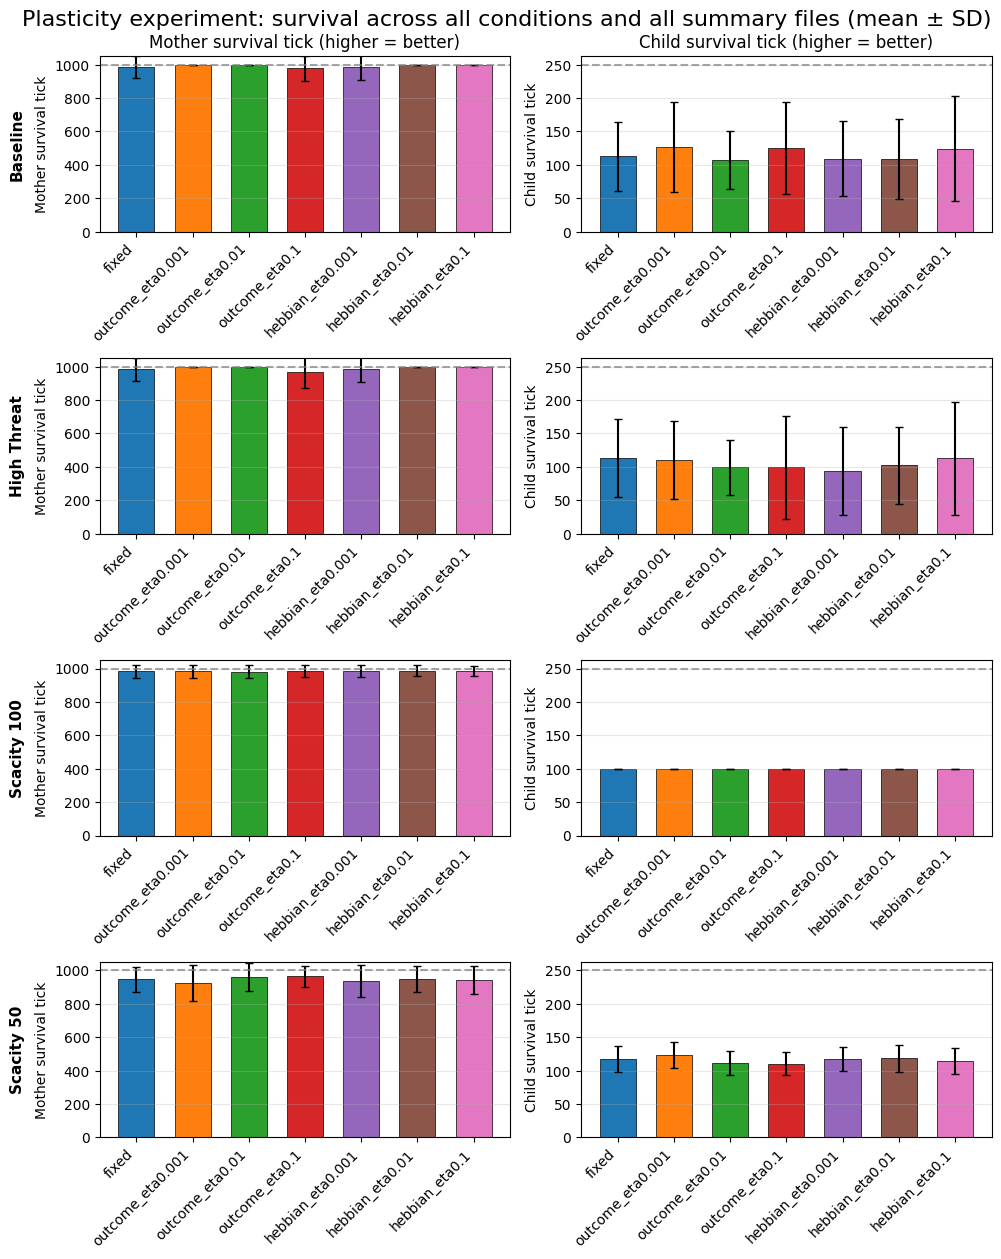

In [17]:
import os
import glob
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


def prettify_scenario_name(path):
    name = os.path.basename(path).replace(".csv", "")
    name = name.replace("experiment_plasticity_", "")
    name = name.replace("_summary", "")
    return name.replace("_", " ").title()


def get_condition_order_and_colors(df_all):
    preferred_order = [
        "fixed",
        "outcome_eta0.001",
        "outcome_eta0.01",
        "outcome_eta0.1",
        "hebbian_eta0.001",
        "hebbian_eta0.01",
        "hebbian_eta0.1",
    ]

    found = df_all["condition"].dropna().unique().tolist()
    condition_order = [c for c in preferred_order if c in found]
    extras = [c for c in found if c not in condition_order]
    condition_order.extend(sorted(extras))

    cmap = plt.get_cmap("tab10")
    color_map = {c: cmap(i % 10) for i, c in enumerate(condition_order)}
    return condition_order, color_map


def plot_all_survival_bars(
    csv_dir,
    mother_max_tick=1000,
    child_max_tick=250,
):
    # find all summary csv files inside your folder
    summary_pattern = os.path.join(csv_dir, "experiment_plasticity_*_summary.csv")
    files = sorted(glob.glob(summary_pattern))

    if not files:
        raise FileNotFoundError(f"No files matched: {summary_pattern}")

    # read once to get shared condition order
    all_dfs = []
    for f in files:
        df = pd.read_csv(f)
        df["source_file"] = os.path.basename(f)
        all_dfs.append(df)

    df_all = pd.concat(all_dfs, ignore_index=True)
    condition_order, color_map = get_condition_order_and_colors(df_all)

    n_files = len(files)
    n_cond = len(condition_order)

    fig, axes = plt.subplots(
        n_files, 2,
        figsize=(max(10, n_cond * 1.0), max(3.2 * n_files, 4.5)),
        squeeze=False
    )

    x = np.arange(n_cond)
    width = max(0.35, min(0.75, 4.5 / max(n_cond, 1)))

    for row, f in enumerate(files):
        df = pd.read_csv(f)
        scenario = prettify_scenario_name(f)

        configs = [
            (axes[row, 0], "mother_survival_tick", "Mother survival tick", mother_max_tick),
            (axes[row, 1], "child_survival_tick", "Child survival tick", child_max_tick),
        ]

        for ax, metric, ylabel, ref_max in configs:
            means = []
            sds = []
            colors = []

            for cond in condition_order:
                sub = df.loc[df["condition"] == cond, metric].dropna()
                means.append(sub.mean() if len(sub) else np.nan)
                sds.append(sub.std(ddof=1) if len(sub) > 1 else 0.0)
                colors.append(color_map[cond])

            ax.bar(
                x, means, width,
                yerr=sds, capsize=3,
                color=colors,
                edgecolor="black",
                linewidth=0.5
            )

            ax.set_xticks(x)
            ax.set_xticklabels(condition_order, rotation=45, ha="right")
            ax.set_ylabel(ylabel)
            ax.set_ylim(0, ref_max * 1.05)
            ax.axhline(ref_max, color="gray", linestyle="--", alpha=0.7)
            ax.grid(axis="y", alpha=0.3)

            if row == 0:
                ax.set_title(f"{ylabel} (higher = better)")

        axes[row, 0].text(
            -0.20, 0.5, scenario,
            transform=axes[row, 0].transAxes,
            rotation=90, va="center", ha="center",
            fontsize=11, fontweight="bold"
        )

    fig.suptitle(
        "Plasticity experiment: survival across all conditions and all summary files (mean ± SD)",
        fontsize=16
    )
    plt.tight_layout()
    return fig


# your csv folder
path = os.path.join(os.getcwd(), "func")

fig = plot_all_survival_bars(
    csv_dir=path,
    mother_max_tick=1000,
    child_max_tick=250,
)
plt.show()

In [84]:
import os
import glob
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


def prettify_scenario_name(path):
    name = os.path.basename(path).replace(".csv", "")
    name = name.replace("experiment_plasticity_", "")
    name = name.replace("_summary", "")
    return name.replace("_", " ").title()


# def get_condition_order_and_colors(df_all):
#     preferred_order = [
#         "fixed",
#         "outcome_eta0.001",
#         "outcome_eta0.01",
#         "outcome_eta0.1",
#         "hebbian_eta0.001",
#         "hebbian_eta0.01",
#         "hebbian_eta0.1",
#     ]

#     found = df_all["condition"].dropna().unique().tolist()
#     condition_order = [c for c in preferred_order if c in found]
#     extras = [c for c in found if c not in condition_order]
#     condition_order.extend(sorted(extras))

#     cmap = plt.get_cmap("tab10")
#     color_map = {c: cmap(i % 10) for i, c in enumerate(condition_order)}
#     return condition_order, color_map

def get_condition_order_and_colors(df_all):

    preferred_order = [
        "fixed",
        "outcome_eta0.001",
        "outcome_eta0.01",
        "outcome_eta0.1",
        "hebbian_eta0.001",
        "hebbian_eta0.01",
        "hebbian_eta0.1",
    ]

    found = df_all["condition"].dropna().unique().tolist()
    condition_order = [c for c in preferred_order if c in found]

    # Behavioral ecology style palette
    color_map = {
        "fixed": "#4D4D4D",

        "outcome_eta0.001": "#9ecae1",
        "outcome_eta0.01": "#3182bd",
        "outcome_eta0.1": "#08519c",

        "hebbian_eta0.001": "#fdd0a2",
        "hebbian_eta0.01": "#f16913",
        "hebbian_eta0.1": "#a63603",
    }

    return condition_order, color_map

def load_all_summary_data(csv_dir, patterns):

    if isinstance(patterns, str):
        patterns = [patterns]

    files = []
    for p in patterns:
        full_pattern = os.path.join(csv_dir, p)
        files.extend(glob.glob(full_pattern))

    # files = (set(files))   # remove duplicates

    scenario_order = [
    "scacity_100",
    "scacity_50",
    "baseline",
    
]

    files.sort(key=lambda x: next(
        (i for i,s in enumerate(scenario_order) if s in x), 999
    ))
    if not files:
        raise FileNotFoundError(f"No files matched: {patterns}")

    dfs = []
    for f in files:
        df = pd.read_csv(f)
        df["scenario"] = prettify_scenario_name(f)
        df["source_file"] = os.path.basename(f)
        dfs.append(df)

    return pd.concat(dfs, ignore_index=True), files

def plot_survival_grouped_by_scenario_bar(
    csv_dir,
    patterns="experiment_plasticity_*_summary.csv",
    mother_max_tick=1000,
    child_max_tick=100,
):
    df_all, files = load_all_summary_data(csv_dir, patterns)

    scenario_order = [prettify_scenario_name(f) for f in files]
    condition_order, color_map = get_condition_order_and_colors(df_all)

    # aggregate mean and sd for each scenario x condition
    agg = (
        df_all.groupby(["scenario", "condition"])
        .agg(
            mother_mean=("mother_survival_tick", "mean"),
            mother_sd=("mother_survival_tick", lambda x: x.std(ddof=1)),
            child_mean=("child_survival_tick", "mean"),
            child_sd=("child_survival_tick", lambda x: x.std(ddof=1)),
        )
        .reset_index()
    )

    n_scen = len(scenario_order)
    n_cond = len(condition_order)

    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(max(12, n_scen * 3.0), 5.5))

    x = np.arange(n_scen)
    group_width = 0.82
    bar_width = group_width / max(n_cond, 1)

    def plot_metric(ax, mean_col, sd_col, ylabel, ref_max):
        for i, cond in enumerate(condition_order):
            means = []
            sds = []

            for scen in scenario_order:
                sub = agg[(agg["scenario"] == scen) & (agg["condition"] == cond)]
                if len(sub):
                    means.append(sub.iloc[0][mean_col])
                    sd_val = sub.iloc[0][sd_col]
                    sds.append(0.0 if pd.isna(sd_val) else sd_val)
                else:
                    means.append(np.nan)
                    sds.append(0.0)

            offsets = x - group_width / 2 + (i + 0.5) * bar_width

            # ax.bar(
            #     offsets,
            #     means,
            #     width=bar_width * 0.95,
            #     yerr=sds,
            #     capsize=3,
            #     color=color_map[cond],
            #     edgecolor="black",
            #     linewidth=0.5,
            #     label=cond,
            # )

            ax.bar(
                offsets,
                means,
                width=bar_width * 0.9,
                yerr=sds,
                capsize=4,
                color=color_map[cond],
                edgecolor="black",
                linewidth=0.7,
                alpha=0.9,
                label=cond,
            )

        ax.set_xticks(x)
        ax.set_xticklabels(scenario_order, rotation=20, ha="right")
        ax.set_ylabel(ylabel)
        ax.set_ylim(0, ref_max * 1.05)
        ax.axhline(ref_max, color="gray", linestyle="--", alpha=0.7)
        ax.grid(axis="y", alpha=0.3)
        ax.set_title(f"{ylabel} across scenarios")

    plot_metric(ax1, "mother_mean", "mother_sd", "Mother survival tick", mother_max_tick)
    plot_metric(ax2, "child_mean", "child_sd", "Child survival tick", child_max_tick)

    handles, labels = ax1.get_legend_handles_labels()
    fig.legend(handles, labels, loc="upper center", ncol=min(len(labels), 4), frameon=False)

    # fig.suptitle(
    #     "Plasticity experiment: scenario-wise comparison of all conditions (mean ± SD)",
    #     fontsize=16,
    #     y=1.03
    # )
    plt.tight_layout(rect=[0, 0, 1, 0.93])
    return fig




In [86]:
def plot_survival_grouped_by_scenario(
    csv_dir,
    patterns="experiment_plasticity_*_summary.csv",
    mother_max_tick=1000,
    child_max_tick=100,
):
    df_all, files = load_all_summary_data(csv_dir, patterns)
    scenario_order = [prettify_scenario_name(f) for f in files]
    condition_order, color_map = get_condition_order_and_colors(df_all)

    agg = (
        df_all.groupby(["scenario", "condition"])
        .agg(
            mother_mean=("mother_survival_tick", "mean"),
            child_mean=("child_survival_tick", "mean"),
        )
        .reset_index()
    )

    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(max(12, len(scenario_order) * 2.5), 5))

    x = np.arange(len(scenario_order))

    for cond in condition_order:
        mother_vals = []
        child_vals = []

        for scen in scenario_order:
            sub = agg[(agg["scenario"] == scen) & (agg["condition"] == cond)]
            if len(sub):
                mother_vals.append(sub.iloc[0]["mother_mean"])
                child_vals.append(sub.iloc[0]["child_mean"])
            else:
                mother_vals.append(np.nan)
                child_vals.append(np.nan)

        ax1.plot(x, mother_vals, marker="o", label=cond, color=color_map[cond])
        ax2.plot(x, child_vals, marker="o", label=cond, color=color_map[cond])

    ax1.set_xticks(x)
    ax1.set_xticklabels(scenario_order, rotation=20, ha="right")
    ax1.set_ylabel("Mother survival tick")
    ax1.set_ylim(900, mother_max_tick * 1.05)
    ax1.axhline(mother_max_tick, color="gray", linestyle="--", alpha=0.7)
    ax1.grid(alpha=0.3)
    ax1.set_title("Mother survival across scenarios")

    ax2.set_xticks(x)
    ax2.set_xticklabels(scenario_order, rotation=20, ha="right")
    ax2.set_ylabel("Child survival tick")
    ax2.set_ylim(80, child_max_tick * 1.05)
    ax2.axhline(child_max_tick, color="gray", linestyle="--", alpha=0.7)
    ax2.grid(alpha=0.3)
    ax2.set_title("Child survival across scenarios")

    handles, labels = ax1.get_legend_handles_labels()
    fig.legend(handles, labels, loc="upper center", ncol=min(len(labels), 4), frameon=False)

    # fig.suptitle("Plasticity experiment: condition trends across scenarios", fontsize=16, y=1.03)
    plt.tight_layout(rect=[0, 0, 1, 0.93])
    return fig


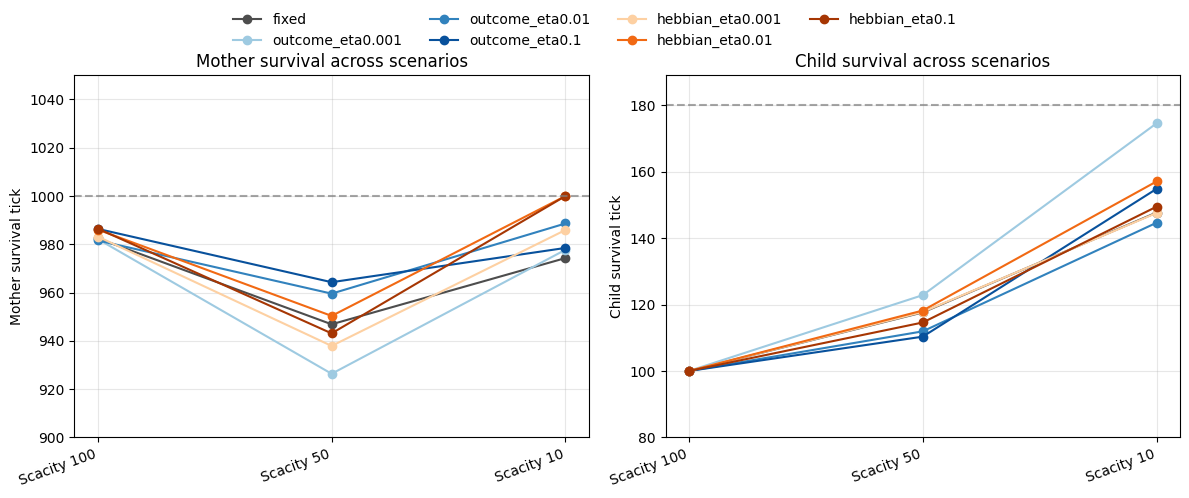

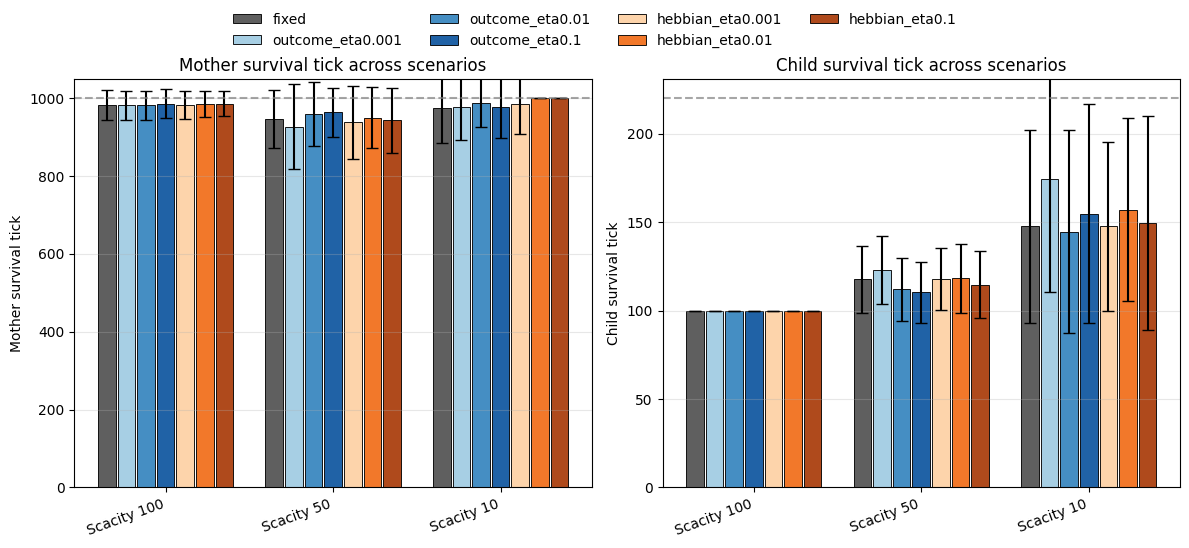

In [96]:
fig = plot_survival_grouped_by_scenario(
    csv_dir=path,
    patterns=[
        # "experiment_plasticity_baseline_summary.csv",
        "experiment_plasticity_scacity_*_summary.csv"
    ],
    mother_max_tick=1000,
    child_max_tick=180
)

# your csv folder
path = os.path.join(os.getcwd(), "func")

fig = plot_survival_grouped_by_scenario_bar(
    csv_dir=path,
    patterns=[
        "experiment_plasticity_scacity_*_summary.csv",
        # "experiment_plasticity_baseline_summary.csv",
    ],
    mother_max_tick=1000,
    child_max_tick=220
)
plt.show()

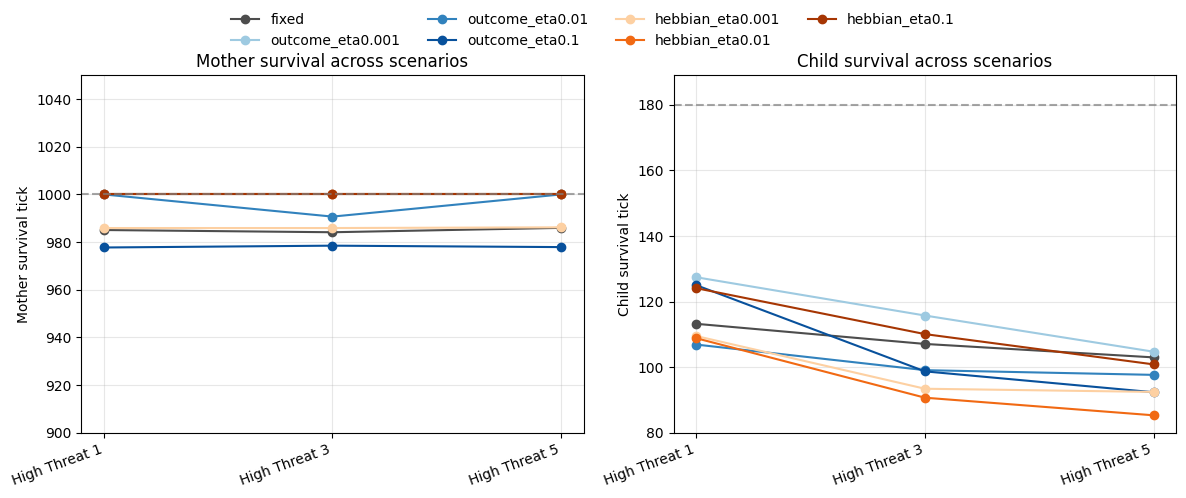

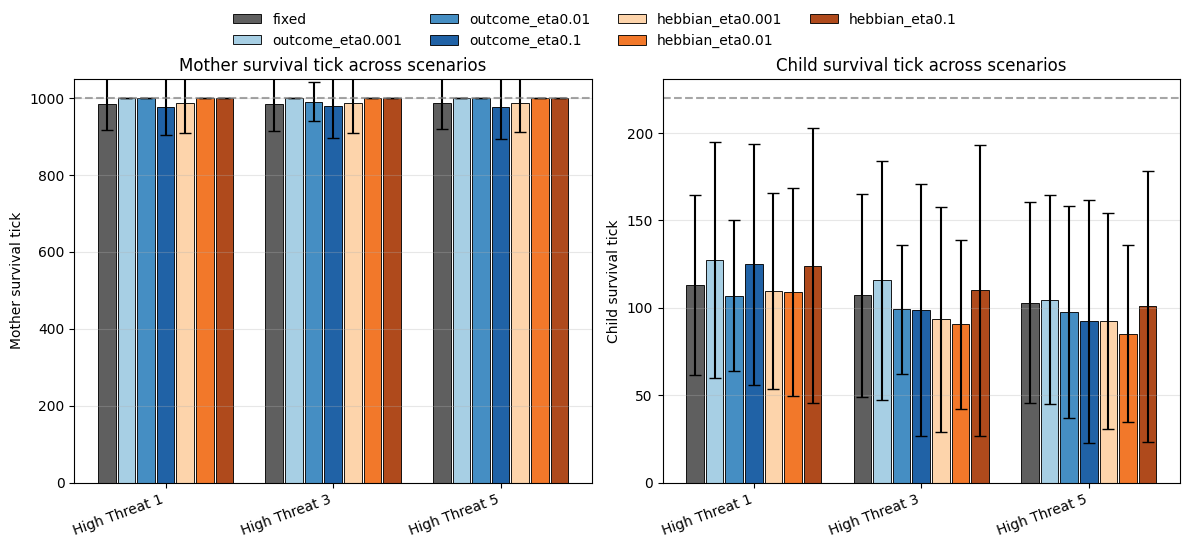

In [95]:
pattern = ["experiment_plasticity_high_threat_*_summary.csv"]

fig = plot_survival_grouped_by_scenario(
    csv_dir=path,
    patterns=pattern,
    mother_max_tick=1000,
    child_max_tick=180
)

# your csv folder
path = os.path.join(os.getcwd(), "func")

fig = plot_survival_grouped_by_scenario_bar(
    csv_dir=path,
    patterns=pattern,
    mother_max_tick=1000,
    child_max_tick=220
)
plt.show()